# Supernova distances and redshifts (Part 2)

In [1]:
import numpy as np
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

In [5]:
import sys
sys.path.append(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks")
from Utilities import plot_settings
from Utilities.utils import train_test_cv_split
import matplotlib.pyplot as plt

In [16]:
X = np.vstack([z_sample, mu_sample, dmu]).T
X_train, X_cv, X_test = train_test_cv_split(X, train_pc=0.5, cv_pc=0.4, test_pc=0.1)

Text(0.5, 1.0, 'Raw Data')

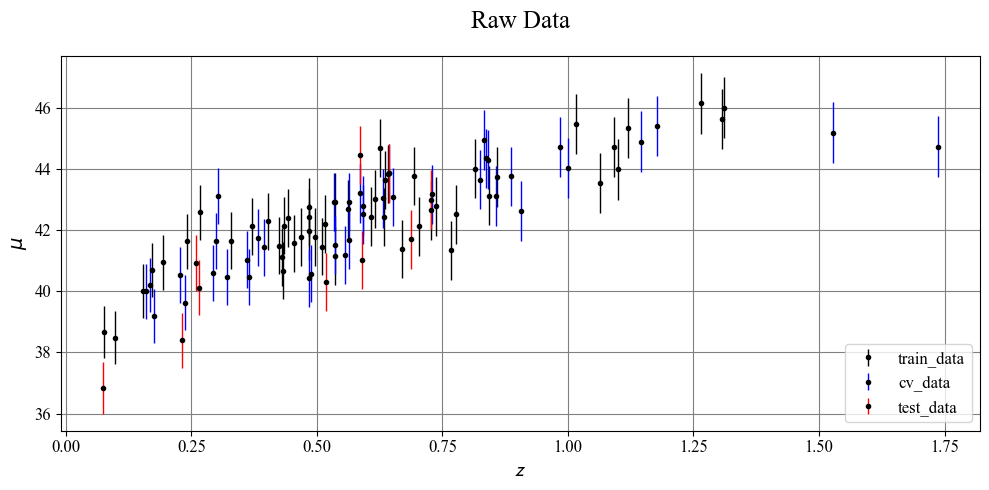

In [7]:
plt.errorbar(X_train[:, 0], X_train[:, 1], yerr=X_train[:, 2], fmt='.k', ecolor='k', lw=1,label='train_data')
plt.errorbar(X_cv[:, 0], X_cv[:, 1], yerr=X_cv[:, 2], fmt='.k', ecolor='blue', lw=1,label='cv_data')
plt.errorbar(X_test[:, 0], X_test[:, 1], yerr=X_test[:, 2], fmt='.k', ecolor='red', lw=1,label='test_data')
plt.xlabel(r"$\mathcal{z}$")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title('Raw Data')

In [8]:
import random
random_seed = 54

np.random.seed(random_seed)
random.seed(random_seed)

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- But check out what's available in the kernels submodule of sklearn.gaussian_process
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, RationalQuadratic
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error

In [11]:
Base_Kernels = [
    RBF(length_scale=0.001, length_scale_bounds=(1e-8, 1e8)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e+1)),
    Matern(length_scale=0.001, length_scale_bounds=(1e-8, 1e8)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e+1)),
    RationalQuadratic(length_scale=0.001) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e+1))
]

In [42]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, RationalQuadratic
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error

# Define base kernels
Base_Kernels = [
    RBF(length_scale=0.001, length_scale_bounds=(1e-8, 1e8)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e+1)),
    Matern(length_scale=0.001, length_scale_bounds=(1e-8, 1e8)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e+1)),
    RationalQuadratic(length_scale=0.001) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e+1))
]

# Custom cross-validation strategy
custom_cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Track best model manually
best_score = -np.inf
best_model = None
best_kernel = None

# Grid search over each kernel
for kernel in Base_Kernels:
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=0, normalize_y=True)

    # Extract proper names for GridSearchCV
    # Kernel is a sum (k1 + k2), where k1 is base, k2 is WhiteKernel
    param_grid = {
        f'kernel__k1__length_scale': np.logspace(-3, -1, 10),
        f'kernel__k2__noise_level': np.logspace(-1, 2, 10)
    }

    grid = GridSearchCV(gpr, 
                        param_grid, 
                        cv=custom_cv, 
                        scoring='neg_mean_squared_error',
                        return_train_score=True)
    grid.fit(X_train[:, 0].reshape(-1, 1), X_train[:, 1])

    score = grid.best_score_
    print(f"Kernel: {kernel}")
    print(f"Best score (neg MSE): {score:.4f}")
    print(f"Best params: {grid.best_params_}\n")

    if score > best_score:
        best_score = score
        best_model = grid.best_estimator_
        best_kernel = kernel

# Final evaluation on test data
y_test_pred = best_model.predict(X_cv[:, 0].reshape(-1, 1))
test_mse = mean_squared_error(X_cv[:, 1], y_test_pred)

print(f"Best kernel: {best_model.kernel_}")
print(f"Test MSE: {test_mse:.3f}")


c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.


Kernel: RBF(length_scale=0.001) + WhiteKernel(noise_level=1)
Best score (neg MSE): -1.0595
Best params: {'kernel__k1__length_scale': np.float64(0.004641588833612777), 'kernel__k2__noise_level': np.float64(0.21544346900318834)}



c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.


Kernel: Matern(length_scale=0.001, nu=1.5) + WhiteKernel(noise_level=1)
Best score (neg MSE): -1.1361
Best params: {'kernel__k1__length_scale': np.float64(0.007742636826811269), 'kernel__k2__noise_level': np.float64(2.1544346900318834)}



c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warning

Kernel: RationalQuadratic(alpha=1, length_scale=0.001) + WhiteKernel(noise_level=1)
Best score (neg MSE): -1.1301
Best params: {'kernel__k1__length_scale': np.float64(0.0016681005372000592), 'kernel__k2__noise_level': np.float64(0.46415888336127786)}

Best kernel: RBF(length_scale=0.723) + WhiteKernel(noise_level=0.324)
Test MSE: 0.908


c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


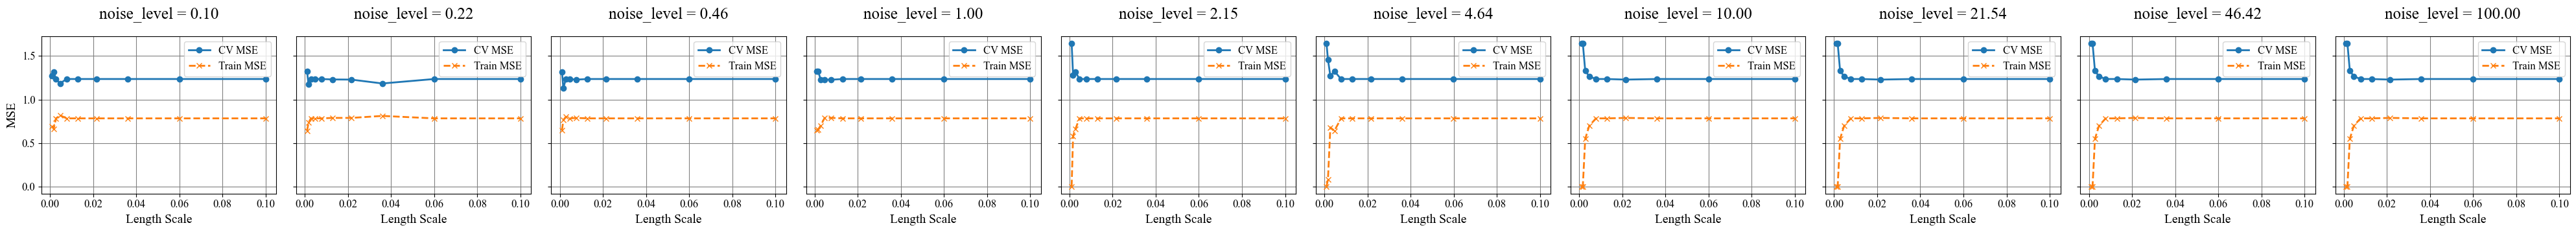

In [43]:
# Extract results
results = grid.cv_results_
mean_train_scores = -results['mean_train_score']
mean_test_scores = -results['mean_test_score']
param_1 = np.array(results['param_kernel__k1__length_scale'].data, dtype=float)
param_2 = np.array(results['param_kernel__k2__noise_level'].data, dtype=float)

# Unique noise levels for subplots
unique_noise_levels = np.unique(param_2)
n_cols = len(unique_noise_levels)

fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), sharey=True)

for i, noise_level in enumerate(unique_noise_levels):
    ax = axes[i] if n_cols > 1 else axes
    mask = param_2 == noise_level

    ax.plot(param_1[mask], mean_test_scores[mask], 'o-', label='CV MSE')
    ax.plot(param_1[mask], mean_train_scores[mask], 'x--', label='Train MSE')

    #ax.set_xscale('log')
    #ax.set_yscale('log')
    ax.set_title(f"noise_level = {noise_level:.2f}")
    ax.set_xlabel('Length Scale')
    if i == 0:
        ax.set_ylabel('MSE')
    ax.grid(True)
    ax.legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [44]:
best_model.fit(X_train[:, 0].reshape(-1,1), X_train[:, 1])

,kernel,RBF(length_sc...e_level=0.215)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,RBF(length_scale=0.00464)
,kernel__k2,WhiteKernel(noise_level=0.215)
,kernel__k1__length_scale,np.float64(0....1588833612777)


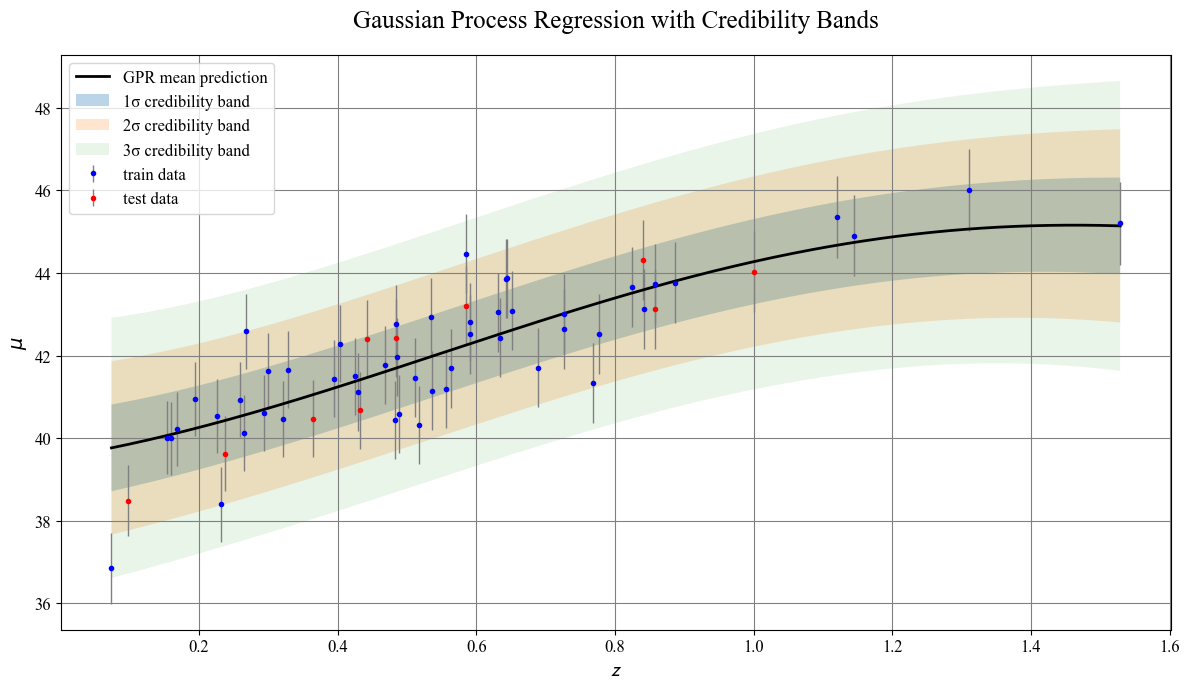

In [45]:
gpr = best_model

# Predict over a dense grid
x_fit = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 300).reshape(-1, 1)
y_mean, y_std = gpr.predict(x_fit, return_std=True)

# Credibility bands: ±1σ, ±2σ, ±3σ
bands = {
    '1σ': (y_mean.ravel() - 1*y_std, y_mean.ravel() + 1*y_std, 0.3),
    '2σ': (y_mean.ravel() - 2*y_std, y_mean.ravel() + 2*y_std, 0.2),
    '3σ': (y_mean.ravel() - 3*y_std, y_mean.ravel() + 3*y_std, 0.1),
}

# Plot
plt.figure(figsize=(12, 7))
plt.errorbar(X_train[:, 0], X_train[:, 1], X_train[:, 2], fmt='.b', ecolor='gray', lw=1, label='train data')
plt.errorbar(X_test[:, 0], X_test[:, 1], X_test[:, 2], fmt='.r', ecolor='gray', lw=1, label='test data')

plt.plot(x_fit, y_mean, 'k-', label='GPR mean prediction')

# Fill credibility regions
for label, (lower, upper, alpha) in bands.items():
    plt.fill_between(x_fit.ravel(), lower, upper, alpha=alpha, label=f'{label} credibility band')

plt.xlabel(r"$\mathcal{z}$")
plt.ylabel(r"$\mu$")
plt.title("Gaussian Process Regression with Credibility Bands")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(X_test[:, 1], gpr.predict(X_test[:,0].reshape(-1,1)))

print(f"Final Test Set Evaluation:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")

Final Test Set Evaluation:
  Mean Squared Error (MSE): 0.6580
